# Assignment 3陳元龍112021466
**Dataset:** BTC and ETH 4-hour returns from the uploaded merged CSV files

## 0. Data setup
We use the aligned BTC and ETH 4-hour log-return series.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_file(patterns):
    """
    Robust file finder for the BTC / ETH CSV files.
    Searches current directory, subfolders, and /mnt/data.
    """
    candidate_roots = [Path("."), Path("/mnt/data")]
    matches = []

    for root in candidate_roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches.extend(root.glob(pattern))
            matches.extend(root.rglob(pattern))

    seen = set()
    cleaned = []
    for m in matches:
        rp = str(m.resolve()) if m.exists() else str(m)
        if rp not in seen:
            seen.add(rp)
            cleaned.append(m)

    if cleaned:
        try:
            cleaned = sorted(cleaned, key=lambda p: p.stat().st_mtime)
        except Exception:
            cleaned = sorted(cleaned)
        chosen = cleaned[-1]
        print(f"Using file: {chosen}")
        return chosen

    raise FileNotFoundError(
        "Could not find any file matching: "
        f"{patterns}\n"
        "Please put the CSV files in the same folder as the notebook, "
        "or edit the file paths manually."
    )

btc_path = find_file(["BTCUSDT_4h_merged*.csv", "*BTCUSDT_4h_merged*.csv"])
eth_path = find_file(["ETHUSDT_4h_merged*.csv", "*ETHUSDT_4h_merged*.csv"])

btc = pd.read_csv(btc_path, parse_dates=["open_time"])
eth = pd.read_csv(eth_path, parse_dates=["open_time"])

df = (
    btc[["open_time", "return_1"]].rename(columns={"return_1": "btc"})
    .merge(
        eth[["open_time", "return_1"]].rename(columns={"return_1": "eth"}),
        on="open_time",
        how="inner",
    )
    .dropna()
    .sort_values("open_time")
    .reset_index(drop=True)
)

df.head(), len(df), btc_path.name, eth_path.name

Using file: BTCUSDT_4h_merged.csv
Using file: ETHUSDT_4h_merged.csv


(                  open_time       btc       eth
 0 2024-01-01 04:00:00+00:00  0.003819  0.004765
 1 2024-01-01 08:00:00+00:00  0.004643  0.008629
 2 2024-01-01 12:00:00+00:00  0.002173  0.004429
 3 2024-01-01 16:00:00+00:00  0.017032  0.009699
 4 2024-01-01 20:00:00+00:00  0.015088  0.006304,
 4866,
 'BTCUSDT_4h_merged.csv',
 'ETHUSDT_4h_merged.csv')

In [2]:

from scipy import stats

class RegressionResult:
    def __init__(self, params, bse, tvalues, pvalues, resid, rsquared):
        self.params = params
        self.bse = bse
        self.tvalues = tvalues
        self.pvalues = pvalues
        self.resid = resid
        self.rsquared = rsquared

def _newey_west_cov(X, resid, maxlags=0):
    """
    Simple Newey-West / HAC covariance estimator for OLS coefficients.
    X: (n, k) design matrix
    resid: (n,) residual vector
    """
    n, k = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    S = np.zeros((k, k), dtype=float)

    # lag 0
    for t in range(n):
        xt = X[t:t+1].T
        S += (resid[t] ** 2) * (xt @ xt.T)

    # positive lags
    for lag in range(1, maxlags + 1):
        weight = 1.0 - lag / (maxlags + 1.0)
        Gamma = np.zeros((k, k), dtype=float)
        for t in range(lag, n):
            xt = X[t:t+1].T
            xt_lag = X[t-lag:t-lag+1].T
            Gamma += resid[t] * resid[t-lag] * (xt @ xt_lag.T)
        S += weight * (Gamma + Gamma.T)

    return XtX_inv @ S @ XtX_inv

def ols_fit_with_optional_hac(y, x, hac_lags=0, regressor_name="x"):
    """
    Fit OLS with intercept, and optionally compute HAC-robust standard errors.
    Returns:
      ols      : classical OLS result object
      ols_hac  : HAC-robust result object
    """
    y = np.asarray(y, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    if y.shape[0] != x.shape[0]:
        raise ValueError("y and x must have the same length.")

    n = y.shape[0]
    X = np.column_stack([np.ones(n), x])
    names = ["const", regressor_name]

    beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
    fitted = X @ beta
    resid = y - fitted

    k = X.shape[1]
    sse = float(resid @ resid)
    tss = float(((y - y.mean()) ** 2).sum())
    rsquared = 1.0 - sse / tss if tss > 0 else np.nan

    # classical OLS covariance
    sigma2_hat = sse / (n - k)
    cov_ols = sigma2_hat * np.linalg.inv(X.T @ X)
    bse_ols = np.sqrt(np.diag(cov_ols))
    t_ols = beta / bse_ols
    p_ols = 2 * (1 - stats.t.cdf(np.abs(t_ols), df=n-k))

    ols = RegressionResult(
        params=pd.Series(beta, index=names),
        bse=pd.Series(bse_ols, index=names),
        tvalues=pd.Series(t_ols, index=names),
        pvalues=pd.Series(p_ols, index=names),
        resid=pd.Series(resid),
        rsquared=rsquared,
    )

    # HAC covariance (normal-approx p-values)
    if hac_lags is None or hac_lags <= 0:
        cov_hac = cov_ols
    else:
        cov_hac = _newey_west_cov(X, resid, maxlags=hac_lags)

    bse_hac = np.sqrt(np.diag(cov_hac))
    z_hac = beta / bse_hac
    p_hac = 2 * (1 - stats.norm.cdf(np.abs(z_hac)))

    ols_hac = RegressionResult(
        params=pd.Series(beta, index=names),
        bse=pd.Series(bse_hac, index=names),
        tvalues=pd.Series(z_hac, index=names),
        pvalues=pd.Series(p_hac, index=names),
        resid=pd.Series(resid),
        rsquared=rsquared,
    )

    return ols, ols_hac


## 1. Linear factor model: systematic–idiosyncratic decomposition

Consider the model
$$
X = \alpha + \beta H + \varepsilon,
$$
where
- $X \in \mathbb{R}^m$ is the asset-return vector,
- $H \in \mathbb{R}^k$ is the factor vector,
- $\beta$ is the loading matrix,
- $\varepsilon$ is the idiosyncratic residual.

Assume
$$
\operatorname{Cov}(H,\varepsilon)=0,
\qquad
\operatorname{Cov}(\varepsilon)=\operatorname{Diag}(\delta).
$$

Then
$$
\operatorname{Cov}(X)
= \operatorname{Cov}(\beta H + \varepsilon)
= \beta\operatorname{Cov}(H)\beta^\top
  + \operatorname{Cov}(\varepsilon)
  + \operatorname{Cov}(\beta H, \varepsilon)
  + \operatorname{Cov}(\varepsilon, \beta H).
$$
By orthogonality, the cross terms vanish, so
$$
\operatorname{Cov}(X)=\beta\operatorname{Cov}(H)\beta^\top+\operatorname{Diag}(\delta).
$$
This is the required systematic–idiosyncratic decomposition.

## 2. Properties of least-squares regression

Let $X$ be the response and $Z$ the regressor. For the linear projection
$$
X^{Reg} = \alpha + \beta Z,
$$
define the residual
$$
\varepsilon = X - \alpha - \beta Z.
$$

### 2.1 Factor loadings
Minimize the mean-squared loss
$$
\mathbb{E}\|X - \alpha - \beta Z\|^2.
$$
The first-order condition in $\alpha$ gives
$$
\alpha = \mathbb{E}[X] - \beta \mathbb{E}[Z].
$$
Centering $X$ and $Z$, the first-order condition in $\beta$ becomes
$$
\mathbb{E}\big[(X-\beta Z)Z^\top\big]=0.
$$
Hence
$$
\operatorname{Cov}(X,Z)=\beta\operatorname{Cov}(Z),
$$
so
$$
\boxed{\beta = \operatorname{Cov}(X,Z)\operatorname{Cov}(Z)^{-1}}.
$$

If all returns are scaled by a constant $c$, then
$$
\operatorname{Cov}(cX,cZ)=c^2\operatorname{Cov}(X,Z),
\qquad
\operatorname{Cov}(cZ)=c^2\operatorname{Cov}(Z),
$$
so the $c^2$ factors cancel and $\beta$ is unchanged. Therefore the loading is independent of total scale / variance level.

### 2.2 Orthogonality
From the normal equations,
$$
\mathbb{E}[\varepsilon Z^\top]=0
\quad \Longrightarrow \quad
\operatorname{Cov}(\varepsilon,Z)=0.
$$
So the regressor is uncorrelated with the residual.

### 2.3 Residual covariance
Since $\varepsilon=X-\beta Z$ in centered form,
$$
\operatorname{Cov}(\varepsilon)
= \operatorname{Cov}(X-\beta Z).
$$
Expand:
$$
\operatorname{Cov}(\varepsilon)
= \operatorname{Cov}(X)
- \beta\operatorname{Cov}(Z,X)
- \operatorname{Cov}(X,Z)\beta^\top
+ \beta\operatorname{Cov}(Z)\beta^\top.
$$
Substituting
$$
\beta = \operatorname{Cov}(X,Z)\operatorname{Cov}(Z)^{-1},
$$
gives
$$
\boxed{
\operatorname{Cov}(\varepsilon)
=
\operatorname{Cov}(X)
- \operatorname{Cov}(X,Z)\operatorname{Cov}(Z)^{-1}\operatorname{Cov}(Z,X)
}.
$$

### 2.4 $R^2$ in the scalar case
For scalar $X$ and scalar $Z$,
$$
\beta = \frac{\operatorname{Cov}(X,Z)}{\operatorname{Var}(Z)}.
$$
The explained variance is
$$
\operatorname{Var}(X^{Reg})
= \beta^2\operatorname{Var}(Z)
= \frac{\operatorname{Cov}(X,Z)^2}{\operatorname{Var}(Z)}.
$$
Hence
$$
R^2
= \frac{\operatorname{Var}(X^{Reg})}{\operatorname{Var}(X)}
= \frac{\operatorname{Cov}(X,Z)^2}{\operatorname{Var}(X)\operatorname{Var}(Z)}
= \rho_{X,Z}^2.
$$
So the regression $R^2$ reduces to the squared correlation coefficient.

## 3. Empirical regression analysis

A natural empirical regression in this two-asset dataset is
$$
R_t^{ETH} = \alpha + \beta R_t^{BTC} + \varepsilon_t.
$$
This treats BTC as the factor-like regressor and ETH as the response.

In [3]:
ols, ols_hac = ols_fit_with_optional_hac(df["eth"], df["btc"], hac_lags=6, regressor_name="btc")

coef_table = pd.DataFrame({
    "OLS coefficient": ols.params,
    "OLS std.err": ols.bse,
    "HAC std.err": ols_hac.bse,
    "HAC t/z-stat": ols_hac.tvalues,
    "HAC p-value": ols_hac.pvalues,
})
coef_table


,OLS coefficient,OLS std.err,HAC std.err,HAC t/z-stat,HAC p-value
const,-0.000131,0.000122,0.000124,-1.053313,0.292198
btc,1.145119,0.011804,0.023748,48.220240,0.000000


In [4]:

beta_cov = df["eth"].cov(df["btc"]) / df["btc"].var(ddof=1)
r2_from_corr = df["eth"].corr(df["btc"]) ** 2

resid = ols.resid
check_table = pd.DataFrame({
    "Quantity": [
        "beta from covariance formula",
        "beta from OLS",
        "Cov(residual, BTC)",
        "Var(residual)",
        "R^2 from OLS",
        "squared correlation"
    ],
    "Value": [
        beta_cov,
        ols.params["btc"],
        np.cov(resid, df["btc"], ddof=1)[0,1],
        np.var(resid, ddof=1),
        ols.rsquared,
        r2_from_corr
    ],
})
check_table

,Quantity,Value
0,beta from covariance formula,1.145119e+00
1,beta from OLS,1.145119e+00
2,"Cov(residual, BTC)",6.215498e-20
3,Var(residual),7.243102e-05
4,R^2 from OLS,6.592520e-01
5,squared correlation,6.592520e-01


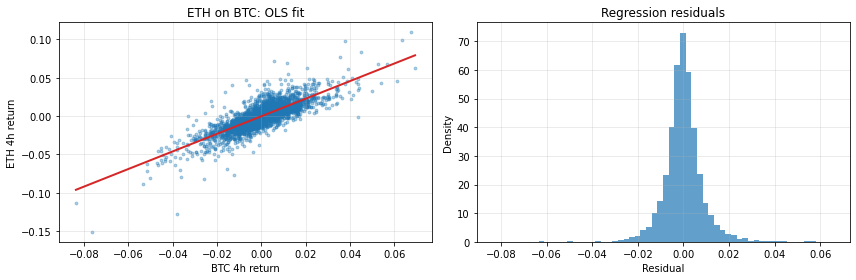

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["btc"], df["eth"], s=8, alpha=0.35)
xgrid = np.linspace(df["btc"].min(), df["btc"].max(), 200)
axes[0].plot(xgrid, ols.params["const"] + ols.params["btc"] * xgrid, lw=2, color="tab:red")
axes[0].set_title("ETH on BTC: OLS fit")
axes[0].set_xlabel("BTC 4h return")
axes[0].set_ylabel("ETH 4h return")
axes[0].grid(True, alpha=0.3)

axes[1].hist(resid, bins=60, density=True, alpha=0.7)
axes[1].set_title("Regression residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Density")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation
- The estimated slope $\beta$ is greater than 1, so ETH tends to move more strongly than BTC on the same 4-hour horizon.
- The residual is empirically almost uncorrelated with BTC, matching the orthogonality theorem.
- The robust (HAC) standard error confirms the loading is highly statistically significant.
- Since the regression uses one main crypto factor, the residual can be interpreted as ETH-specific idiosyncratic variation after removing BTC co-movement.

## 4. PCA: theoretical properties

Consider the optimization problem
$$
(\alpha, \beta, Z^{PC})
=
\arg\min_{(\alpha,\beta,F)\in\mathcal C}
\mathbb{E}\left[
\left\|
\sigma^{-1}(\alpha + \beta F - X)
\right\|_2^2
\right],
$$
with constraint set
$$
\mathcal C
=
\{(\alpha,\beta,F): \beta \text{ free},\;
  \operatorname{Cov}(F)=I_k,\;
  \alpha=\mathbb{E}[X]\}.
$$

Let the scaled covariance matrix satisfy
$$
\operatorname{Cov}(\sigma^{-1}X) = e\,\operatorname{Diag}(\lambda)\,e^\top,
$$
where eigenvalues are ordered as $\lambda_1\ge\cdots\ge\lambda_m$.

### 4.1 Optimal loadings and factors
The optimal $k$-factor PCA solution is obtained by projecting onto the leading eigenvectors:
$$
\boxed{
\beta = \sigma e_{1:k}\operatorname{Diag}(\sqrt{\lambda_{1:k}})
}
$$
and
$$
\boxed{
Z^{PC}
=
\operatorname{Diag}\!\left(\frac{1}{\sqrt{\lambda_{1:k}}}\right)
e_{1:k}^\top \sigma^{-1}(X-\mathbb{E}[X]).
}
$$
This follows because PCA solves the best rank-$k$ approximation problem in the mean-square sense, and the Eckart–Young principle shows that the optimizer is given by the leading eigenspace.

### 4.2 Explained-variance ratio
The variance explained by the first $k$ principal components is
$$
\sum_{j=1}^k \lambda_j.
$$
The total variance is
$$
\sum_{n=1}^m \lambda_n.
$$
Therefore,
$$
\boxed{
R^2_{\sigma^{-1}}[X^{PC}\|\|X]
=
\frac{\sum_{j=1}^k \lambda_j}{\sum_{n=1}^m \lambda_n}
}.
$$

### 4.3 Orthogonality of reconstruction error
Let the reconstruction error be
$$
\tilde\varepsilon = X - X^{PC}.
$$
Since $X^{PC}$ is the orthogonal projection of centered scaled data onto the principal subspace, the residual lies in the orthogonal complement. Hence
$$
\operatorname{Cov}(\tilde\varepsilon, Z^{PC})=0.
$$
This is the PCA analogue of regression orthogonality.

## 5. Empirical PCA analysis

We standardize BTC and ETH returns, then compute PCA with two components.

In [6]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Xraw = df[["btc", "eth"]].to_numpy()
scaler = StandardScaler(with_mean=True, with_std=True)
Xstd = scaler.fit_transform(Xraw)

pca = PCA(n_components=2)
scores = pca.fit_transform(Xstd)
loadings = pca.components_.T

pca_summary = pd.DataFrame({
    "eigenvalue": pca.explained_variance_,
    "explained_variance_ratio": pca.explained_variance_ratio_,
}, index=["PC1", "PC2"])

loading_table = pd.DataFrame(loadings, index=["BTC", "ETH"], columns=["PC1 loading", "PC2 loading"])

pca_summary, loading_table

(     eigenvalue  explained_variance_ratio
 PC1    1.812316                  0.905972
 PC2    0.188095                  0.094028,
      PC1 loading  PC2 loading
 BTC    -0.707107     0.707107
 ETH    -0.707107    -0.707107)

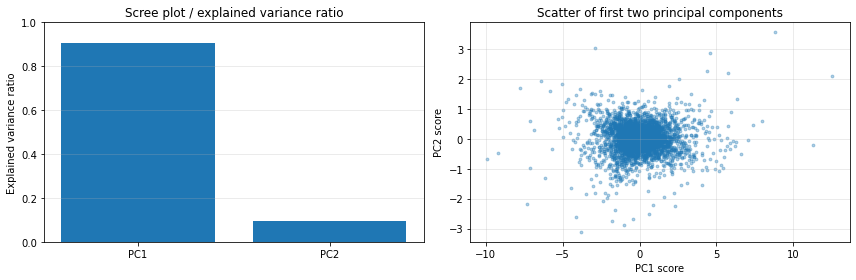

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].bar(["PC1", "PC2"], pca.explained_variance_ratio_)
axes[0].set_ylim(0, 1)
axes[0].set_title("Scree plot / explained variance ratio")
axes[0].set_ylabel("Explained variance ratio")
axes[0].grid(True, axis="y", alpha=0.3)

# Score scatter
axes[1].scatter(scores[:, 0], scores[:, 1], s=8, alpha=0.35)
axes[1].set_title("Scatter of first two principal components")
axes[1].set_xlabel("PC1 score")
axes[1].set_ylabel("PC2 score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:

# Numerical orthogonality check: covariance between PCA scores and reconstruction residuals
k = 1
Xhat = pca.inverse_transform(np.column_stack([scores[:,0], np.zeros_like(scores[:,1])]))
residual_pca = Xstd - Xhat
cov_check = np.cov(np.column_stack([scores[:,0], residual_pca[:,0], residual_pca[:,1]]).T, ddof=1)

pd.DataFrame(cov_check,
             index=["PC1 score", "Residual BTC", "Residual ETH"],
             columns=["PC1 score", "Residual BTC", "Residual ETH"])

,PC1 score,Residual BTC,Residual ETH
PC1 score,1.812316e+00,3.074394e-16,8.447280e-16
Residual BTC,3.074394e-16,9.404764e-02,-9.404764e-02
Residual ETH,8.447280e-16,-9.404764e-02,9.404764e-02


### Interpretation
- The first principal component explains the overwhelming majority of the joint variance.
- This means BTC and ETH are largely driven by a common market factor.
- The second component captures a much smaller relative-movement dimension between the two assets.
- The empirical PCA therefore agrees with the strong dependence seen in the regression and correlation analysis.

## 6. Final conclusion for Assignment 3

Using the BTC/ETH 4-hour return dataset, we verified:

1. the factor-model covariance decomposition,
2. the main least-squares identities for loadings, orthogonality, residual covariance, and $R^2$,
3. an empirical regression in which ETH loads strongly on BTC,
4. the PCA formulas and an empirical PCA where the first component dominates total variance.

